# Normalization

https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
pd.set_option('display.max_columns', None)

## Visualize Data Distribution

In [4]:
df = pd.read_csv('glass.data',names=['Id','RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','type_int'])

In [5]:
df.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,type_int
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [41]:
X = df.loc[:,'RI':'Fe']

In [42]:
y = df['type_int']

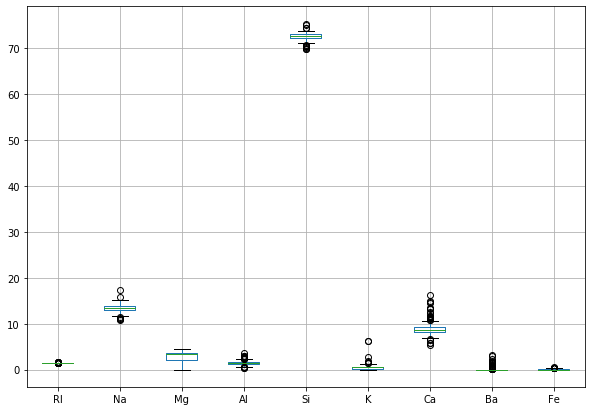

In [43]:
plt.figure(figsize=(10,7))
X.boxplot()

If you prefer seaborn:

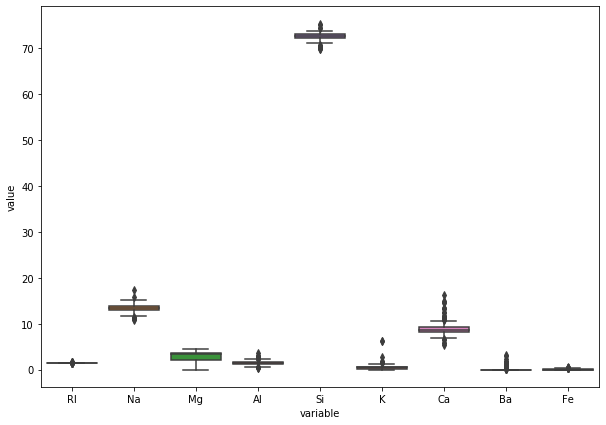

In [44]:
plt.figure(figsize=(10,7))
sns.boxplot(x="variable", y="value", data=pd.melt(X));

## Split Dataset

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)

## Standardization (mean removal and variance scaling)

In [35]:
from sklearn import preprocessing

In [50]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)

StandardScaler(copy=True, with_mean=True, with_std=True)

In [51]:
scaler.mean_

array([1.51846503e+00, 1.33924561e+01, 2.69327485e+00, 1.44649123e+00,
       7.26111696e+01, 5.12222222e-01, 8.99228070e+00, 1.67719298e-01,
       6.12280702e-02])

In [52]:
scaler.scale_

array([0.00314351, 0.76207538, 1.43650845, 0.49679261, 0.79069799,
       0.71271475, 1.48886945, 0.47815686, 0.10168298])

In [55]:
X_train_normalized = scaler.transform(X_train)

In [58]:
X_train_normalized.mean(axis=0)

array([ 5.82458058e-14,  2.79438591e-15,  5.45372714e-17, -3.01253499e-16,
        4.30325041e-15, -3.76566874e-17, -7.58327774e-16,  7.53133748e-17,
       -1.29850646e-16])

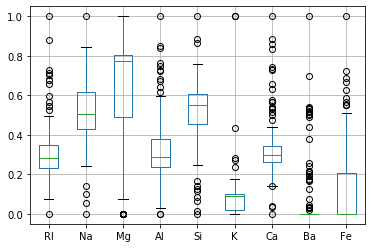

In [86]:
df_train_normalized = X_train.copy()
df_train_normalized.loc[:,'RI':'Fe'] = X_train_normalized
df_train_normalized.boxplot();

We train the model using `X_train_noramlized`, then to predict any value `v`, first you use `scaler.transform(v)`, then you pass the result to the trained model

In [71]:
X_test_normalized = scaler.transform(X_test)
# y_pred = model.predict(X_test_normalized)

## Scaling features to a range

In [80]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
scaler.fit(X_train)

MinMaxScaler(copy=True, feature_range=(0, 1))

In [82]:
X_train_normalized = scaler.transform(X_train)

In [83]:
X_train_normalized.min(axis=0)

array([0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [84]:
X_train_normalized.max(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

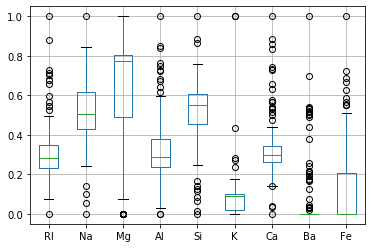

In [87]:
df_train_normalized = X_train.copy()
df_train_normalized.loc[:,'RI':'Fe'] = X_train_normalized
df_train_normalized.boxplot();